<a href="https://colab.research.google.com/github/theoneureka/Computer-Vision-Project/blob/oshawott/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Object Classification Using YOLO <b> </h1></center>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This tutorial is designed to provide a comprehensive understanding of how to use YOLO, a state-of-the-art method in computer vision, for detecting objects in images.

Object detection and classification is a key technology in many areas, such as automated vehicles, security, and even healthcare.

We will begin with the basics of preparing (pre processing) an image dataset, ensuring it is ready for effective model training.We will then explore how YOLO, a type of convolutional neural network, automatically extracts features from images to recognize different objects. Understanding this process is crucial for grasping how YOLO operates.

The core of this tutorial is focused on transfer learning using YOLO. We will teach you how to take a pre-trained YOLO model and adapt it to a new dataset. This technique is efficient and powerful, allowing us to harness the strengths of YOLO with less computational effort.

By the end of this tutorial, you will have hands-on experience with preparing data, implementing YOLO, and understanding the principles behind it. This tutorial aims to equip students with practical skills and knowledge in one of the most exciting fields in technology.

Since its inception, the YOLO family of object detection models has come a long way. YOLOv8 is the most recent addition to this famous anchor-based single-shot family of object detectors. It comes with a bunch of improvements which include state-of-the-art accuracy and speed.  In this article, we will be fine tuning the YOLOv8 object detection model on a real-world pothole detection dataset.

In the previous lecture, you were asked to make your own custom datasets for a project you want to work on. Today we will explore how to finetune YOLO on a certain dataset.  

Importing required Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

# Dataset Description






Fruit Images for Object Detection

available on kaggle => https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection


- 240 images in train folder. 60 images in test folder.

- 3 different fruits:

    - Apple

    - Banana

    - Orange

The labels are in xml format, which is Extensible markup language.Storing image dataset labels in XML format is quite common. XML provides a clear, hierarchical structure which is ideal for representing the complex data associated with image labels. This includes not just the class of the object, but potentially a wealth of other information like bounding box coordinates, object IDs, and additional metadata.


# Data Preprocessing

For preprocessing:
- We have to convert the dataset into that acceptable by YOLO.
  - Heirarchy of folders should be the one accepted by YOLO
  - Labels format should be darknet YOLO.
  - Labels files should be .txt files
- Check and see if there are any missing labels or images. And remove them from dataset.


## Heirarchy of Folders correction

Defining paths to train and test folders.

In [18]:
test_dir = '/content/drive/MyDrive/toxic/test_zip/test'
train_dir = '/content/drive/MyDrive/toxic/train_zip/train'

test_dir2 = '/content/drive/MyDrive/ntoxic/test_zip/test'
train_dir2 = '/content/drive/MyDrive/ntoxic/train_zip/train'



The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

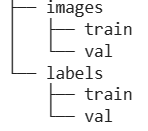


Making directories according to above struture of folders

In [23]:
#import os
#run it once for making directories

#os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data')
os.makedirs("/content/drive/MyDrive/Tutorials/Datasets/Final_data/images/train/toxic", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Tutorials/Datasets/Final_data/images/train/nontoxic", exist_ok=True)

os.makedirs("/content/drive/MyDrive/Tutorials/Datasets/Final_data/images/val/toxic", exist_ok=True)
os.makedirs("/content/drive/MyDrive/Tutorials/Datasets/Final_data/images/val/nontoxic", exist_ok=True)

In [24]:
#set the paths to images directory
image_dir="/content/drive/MyDrive/Tutorials/Datasets/Final_data/images"

Copy XML files and jpg files from the train folder to the folders created.

In [26]:
#import shutil
#run it once for copying!
for file in os.listdir(train_dir):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/toxic", new_filename), "JPEG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))


#Copy XML files and jpg files from the test folder to the folders created.
for file in os.listdir(test_dir):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(test_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/toxic", new_filename), "JPEG")
        #shutil.copy(os.path.join(test_dir, file), os.path.join(image_dir, "val"))


In [27]:
for file in os.listdir(train_dir2):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir2, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train/nontoxic", new_filename), "JPEG")
        #shutil.copy(os.path.join(train_dir2, file), os.path.join(image_dir, "train"))


#Copy XML files and jpg files from the test folder to the folders created.
for file in os.listdir(test_dir2):
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(test_dir2, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val/nontoxic", new_filename), "JPEG")
        #shutil.copy(os.path.join(test_dir2, file), os.path.join(image_dir, "val"))

Visualizing somme pictures from the dataset

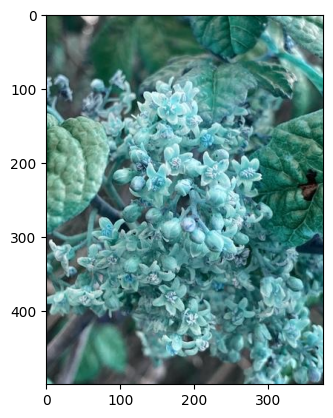

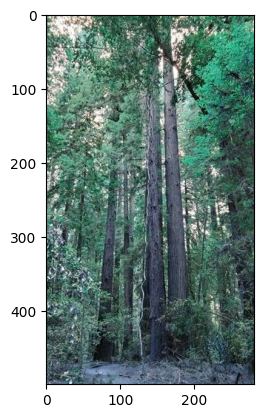

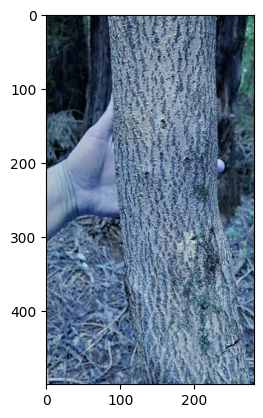

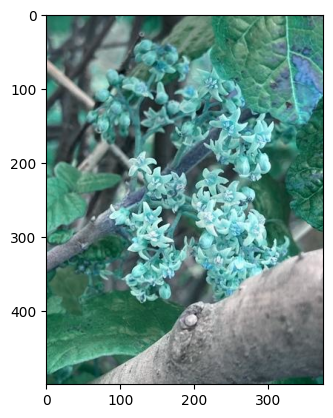

In [33]:
#visualize first four sample images from train data
for idx, image in enumerate(os.listdir(os.path.join(image_dir, "train/toxic"))):
    img = cv2.imread(os.path.join(image_dir,"train/toxic", image), 1)
    plt.imshow(img)
    plt.show()

    if idx == 3:
        break

If there are more than one bounding boxes in single image, they should be written in one text file. As, you can see in the below example that one image has so many bounding boxes.

In [34]:
filtered_df = train_df[train_df['name'] == train_df["name"][3]]
(filtered_df.head(15))

NameError: name 'train_df' is not defined

In [37]:
#file_name = [x.split('.')[0] for x in df1["name"]]

#TRAINING DATA
#finding all the unique names:
unique_names= train_df['name'].unique()

#for each unique name, containing multiple bboxes, combine them together.
for name in unique_names:
  data = train_df[train_df.name == name]
  box_list = []
  for idx in range(len(data)):
        row = data.iloc[idx]
        box_list.append(row['class']+" "+row['x_center']+" "+row['y_center']+" "+ row['box_width']+" "+row['box_height'])

#writing on text files
  text = "\n".join(box_list)
  with open(f'{label_dir}/train/{name}.txt', 'w') as file:
            file.write(text)
#############################################################################################
#VALIDATION DATA
#finding all the unique names:
unique_names= val_df['name'].unique()

#for each unique name, containing multiple bboxes, combine them together.
for name in unique_names:
  data = val_df[val_df.name == name]
  box_list = []
  for idx in range(len(data)):
        row = data.iloc[idx]
        box_list.append(row['class']+" "+row['x_center']+" "+row['y_center']+" "+ row['box_width']+" "+row['box_height'])

#writing on text files
  text = "\n".join(box_list)
  with open(f'{label_dir}/val/{name}.txt', 'w') as file:
            file.write(text)

In [41]:
# Find extra files in each folder

#TRAINING DATA
extra_images_train = image_files_train - label_files_train
extra_labels_train = label_files_train - image_files_train

# Output the results
print(f"Training Extra images (without corresponding labels): {extra_images_train}")
print(f"Training Extra labels (without corresponding images): {extra_labels_train}")


#VALIDATION DATA
extra_images_val = image_files_val - label_files_val
extra_labels_val = label_files_val - image_files_val

# Output the results
print(f"Validation Extra images (without corresponding labels): {extra_images_val}")
print(f"Validation Extra labels (without corresponding images): {extra_labels_val}")

Training Extra images (without corresponding labels): {'049', '031', '033', '017', '030', '003', '004', '022', '036', '020', '026', '048', '032', '019', '001', '039', '041', '013', '014', '016', '005', '011', '018', '025', '023', '002', '043', '038', '015', '029', '024', '009', '042', '000', '012', '006', '044', '008', '021', '046', '040', '007', '047', '027', '010', '035', '045', '037', '034', '028'}
Training Extra labels (without corresponding images): set()
Validation Extra images (without corresponding labels): {'002', '011', '017', '015', '003', '004', '022', '020', '024', '009', '012', '000', '006', '008', '021', '019', '001', '007', '013', '014', '018', '005', '016', '010', '023'}
Validation Extra labels (without corresponding images): set()


Make sure that the above info is correct by chceking the data manually.

Now removing from the dataset:

In [35]:
for file in extra_images_train:
     os.remove(os.path.join(image_dir, "train", file + '.jpg')) # or '.png' depending on your image format

for file in extra_images_val:
     os.remove(os.path.join(image_dir, "val", file + '.jpg'))

NameError: name 'extra_images_train' is not defined

Now run the above cells again to find if all the missing data is deleted.

# Custom object detection using YOLO

First install and import

In [36]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [37]:
from ultralytics import YOLO

## Training YOLO

In [49]:
model = YOLO('yolov8n-cls.pt') # pretrained model

The detailed architecture of the model can be seen from:


In [50]:
model

YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

In [52]:
model.train(data="/content/drive/MyDrive/Tutorials/Datasets/Final_data/images",epochs=5,patience=5,batch=8, lr0=0.0005,imgsz=640,project="/content/drive/MyDrive/custom_folder")

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Tutorials/Datasets/Final_data/images, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimiz

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b98340f9a60>
curves: []
curves_results: []
fitness: 0.8300000131130219
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.6600000262260437, 'metrics/accuracy_top5': 1.0, 'fitness': 0.8300000131130219}
save_dir: PosixPath('/content/drive/MyDrive/custom_folder/train-3')
speed: {'preprocess': 0.7903002999955788, 'inference': 9.304921719985941, 'loss': 0.0008803599939710693, 'postprocess': 0.0014390600063052261}
top1: 0.6600000262260437
top5: 1.0

Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [56]:
metrics = model.val(project="/content/drive/MyDrive/custom_folder")  # no other arguments needed, dataset and settings remembered

print(metrics.top1)

Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
train: /content/drive/MyDrive/Tutorials/Datasets/Final_data/images/train... found 100 images in 2 classes ✅ 
val: /content/drive/MyDrive/Tutorials/Datasets/Final_data/images/val... found 50 images in 2 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.7±0.4 ms, read: 17.2±6.7 MB/s, size: 34.0 KB)
val: Scanning /content/drive/MyDrive/Tutorials/Datasets/Final_data/images/val... 50 images, 0 corrupt: 100% ━━━━━━━━━━━━ 50/50 14.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 4/4 1.3it/s 3.2s
                   all       0.66          1
Speed: 7.8ms preprocess, 2.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/drive/MyDrive/custom_folder/val-6
0.6600000262260437


Showing confusion matrix, that is already stored in detect/train folder

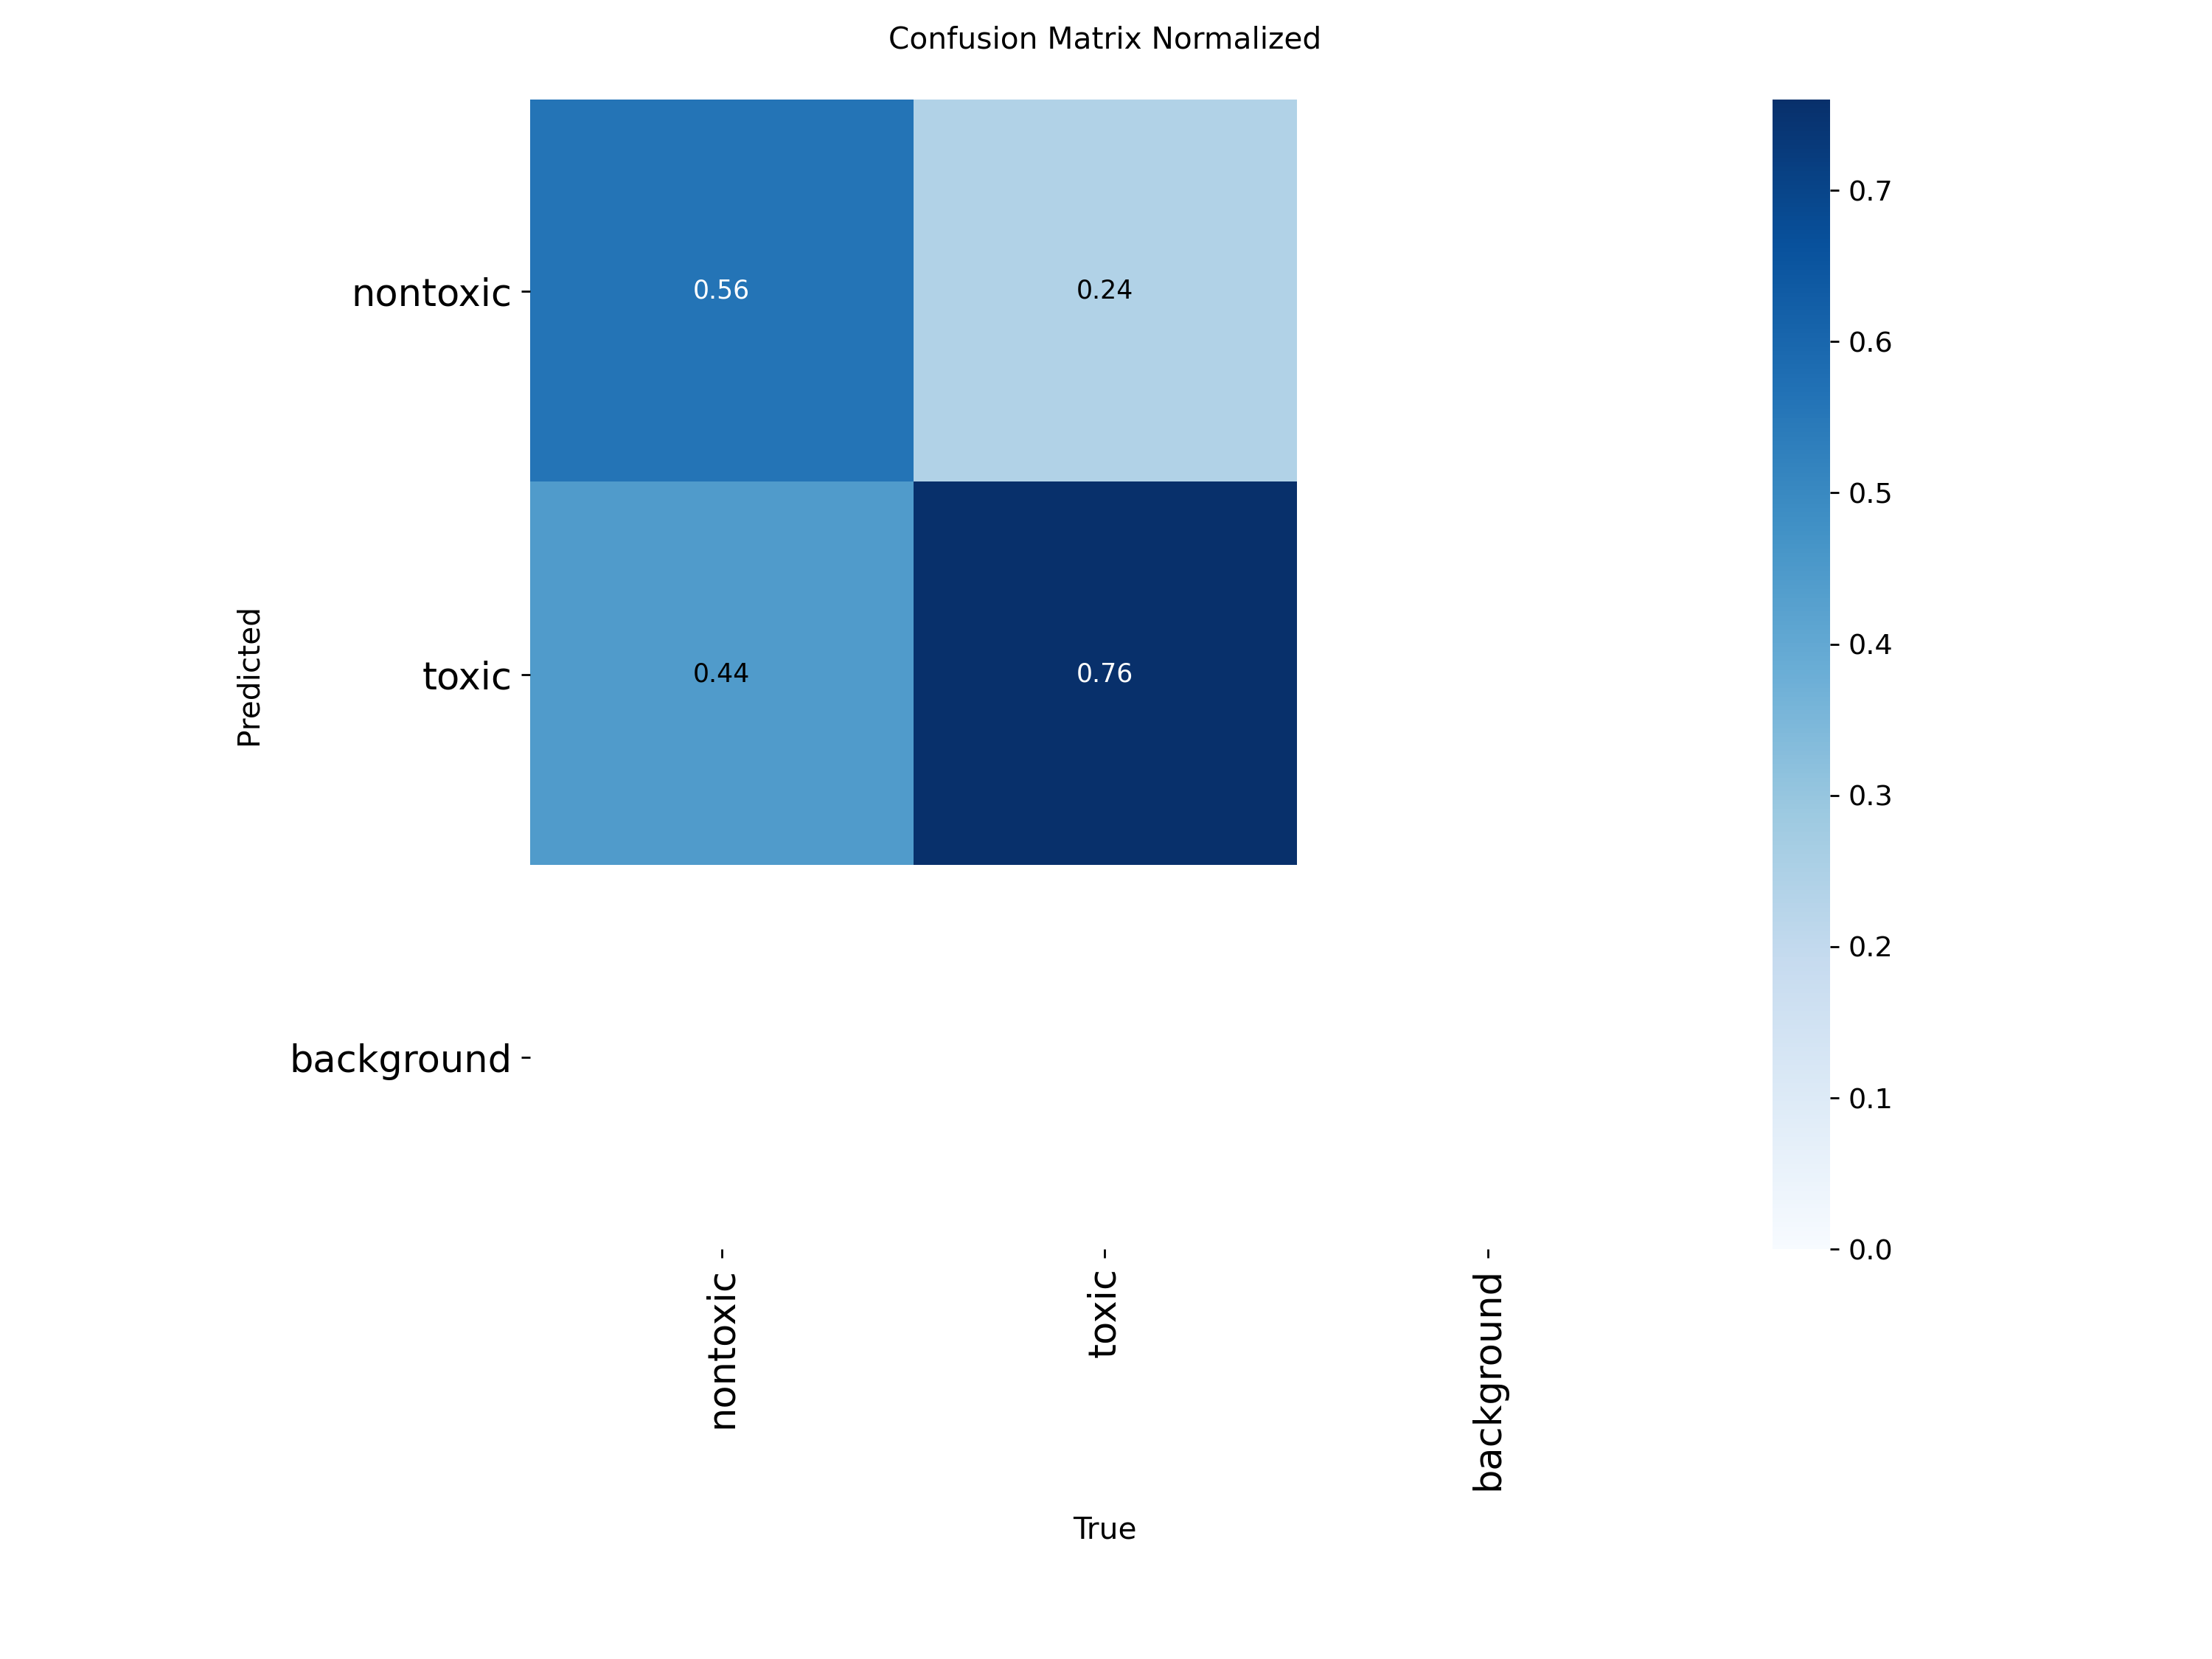

In [57]:
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/custom_folder/train-3/confusion_matrix_normalized.png')

##Prediction

In [ ]:
model = YOLO("/content/drive/MyDrive/custom_folder/my_experiment/weights/best.pt")  # load a custom model

# Predict with the model with any image from internet?
results = model('https://www.freshpoint.com/wp-content/uploads/2019/08/freshpoint-produce-101-apples-bananas.jpg', save=True, project="/content/drive/MyDrive/custom_folder")


Found https://www.freshpoint.com/wp-content/uploads/2019/08/freshpoint-produce-101-apples-bananas.jpg locally at freshpoint-produce-101-apples-bananas.jpg
image 1/1 /content/freshpoint-produce-101-apples-bananas.jpg: 576x640 2 apples, 3 bananas, 16.4ms
Speed: 2.3ms preprocess, 16.4ms inference, 1.7ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /content/drive/MyDrive/custom_folder/predict-2


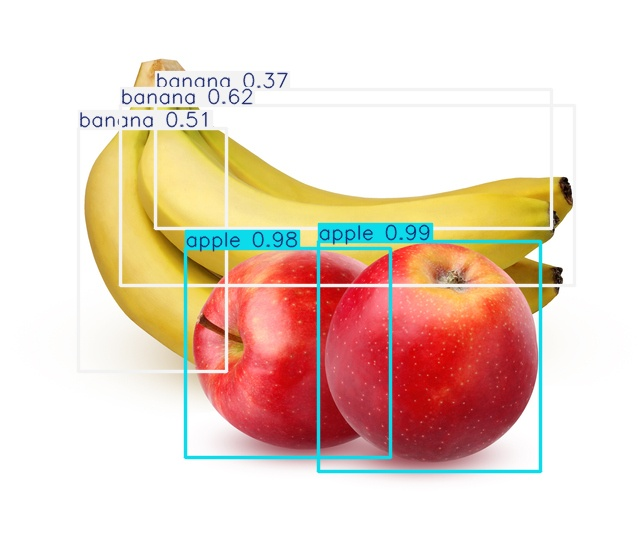

In [ ]:
# SHOW THE IMAGE STORED
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/custom_folder/predict-2/freshpoint-produce-101-apples-bananas.jpg')